In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import yaml
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Base path
RESULTS_DIR = Path('results')

In [35]:
class ResultAnalyzer:
    """Analyze and compare training results from different configurations."""

    def __init__(self, results_dir=RESULTS_DIR):
        self.results_dir = Path(results_dir)
        self.experiments = {}
        self.load_all_results()

    def load_all_results(self):
        """Load all result directories."""
        for result_dir in sorted(self.results_dir.iterdir()):
            if result_dir.is_dir():
                exp_name = result_dir.name
                print(f"Loading experiment: {exp_name}")
                self.experiments[exp_name] = self._load_experiment(result_dir)
        print(f"\nLoaded {len(self.experiments)} experiments\n")

    def _load_experiment(self, exp_dir):
        """Load a single experiment's data and config."""
        exp_data = {'directory': exp_dir}

        config_file = exp_dir / 'config_snapshot.yaml'
        if config_file.exists():
            with open(config_file, 'r') as f:
                exp_data['config'] = yaml.safe_load(f)

        train_metrics_file = exp_dir / 'metrics' / 'training_metrics.csv'
        if train_metrics_file.exists():
            exp_data['train_metrics'] = pd.read_csv(train_metrics_file)

        val_metrics_file = exp_dir / 'metrics' / 'validation_metrics.csv'
        if val_metrics_file.exists():
            exp_data['val_metrics'] = pd.read_csv(val_metrics_file)

        test_metrics_file = exp_dir / 'metrics' / 'test_metrics.csv'
        if test_metrics_file.exists():
            exp_data['test_metrics'] = pd.read_csv(test_metrics_file)

        exp_data['symbol'] = self._infer_symbol(exp_data)
        return exp_data

    def _infer_symbol(self, exp_data):
        """Infer trading symbol from config filename."""
        config = exp_data.get('config', {})
        csv_file = str(config.get('data', {}).get('csv_file', '')).upper()
        if 'CORN' in csv_file:
            return 'CORN'
        if 'USDCNH' in csv_file or 'CNH' in csv_file:
            return 'CNH'
        return 'UNKNOWN'

    def _normalize_symbol(self, symbol):
        """Normalize symbol filter input."""
        if symbol is None:
            return 'ALL'
        symbol = str(symbol).strip().upper()
        if symbol in {'ALL', '*', ''}:
            return 'ALL'
        if symbol in {'USDCNH', 'CNH'}:
            return 'CNH'
        if symbol == 'CORN':
            return 'CORN'
        return symbol

    def _filter_experiments(self, symbol='all'):
        """Return experiments filtered by symbol."""
        normalized = self._normalize_symbol(symbol)
        if normalized == 'ALL':
            return self.experiments
        return {
            exp_name: exp_data
            for exp_name, exp_data in self.experiments.items()
            if exp_data.get('symbol', 'UNKNOWN') == normalized
        }

    def get_summary(self, symbol='all'):
        """Get summary of experiments, optionally filtered by symbol."""
        summaries = []
        filtered = self._filter_experiments(symbol)

        for exp_name, exp_data in filtered.items():
            summary = {
                'Experiment': exp_name,
                'Symbol': exp_data.get('symbol', 'UNKNOWN'),
                'Has Train Metrics': 'train_metrics' in exp_data,
                'Has Val Metrics': 'val_metrics' in exp_data,
                'Has Test Metrics': 'test_metrics' in exp_data,
            }

            if 'config' in exp_data:
                config = exp_data['config']
                summary['Model'] = f"d_model={config.get('model', {}).get('d_model')}"
                summary['Dropout'] = config.get('model', {}).get('dropout')
                summary['Layers'] = config.get('model', {}).get('num_layers')

            if 'val_metrics' in exp_data:
                val_df = exp_data['val_metrics']
                final_loss = val_df['total_loss'].iloc[-1]
                best_loss = val_df['total_loss'].min()
                summary['Final Loss'] = f"{final_loss:.4f}"
                summary['Best Loss'] = f"{best_loss:.4f}"

            if 'test_metrics' in exp_data:
                test_df = exp_data['test_metrics']
                if not test_df.empty and 'accuracy' in test_df.columns:
                    summary['Test Acc'] = f"{test_df['accuracy'].iloc[-1]:.4f}"

            summaries.append(summary)

        return pd.DataFrame(summaries)

    def plot_comparison(self, metric='total_loss', metric_type='val', symbol='all'):
        """Plot metric comparison across experiments with optional symbol filter."""
        filtered = self._filter_experiments(symbol)
        normalized = self._normalize_symbol(symbol)
        suffix = f" ({normalized})" if normalized != 'ALL' else ''

        if metric_type == 'test':
            rows = []
            for exp_name, exp_data in filtered.items():
                if 'test_metrics' in exp_data:
                    df = exp_data['test_metrics']
                    if not df.empty and metric in df.columns:
                        rows.append((exp_name, float(df[metric].iloc[-1])))

            if not rows:
                print(f"No test metric '{metric}' found for filter {normalized}.")
                return

            rows.sort(key=lambda x: x[1], reverse=True)
            labels = [x[0] for x in rows]
            values = [x[1] for x in rows]

            fig, ax = plt.subplots(figsize=(14, 6))
            ax.bar(labels, values)
            ax.set_xlabel('Experiment', fontsize=12)
            ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
            ax.set_title(f"Test {metric.replace('_', ' ').title()} Comparison{suffix}", fontsize=14)
            ax.grid(True, alpha=0.3, axis='y')
            ax.tick_params(axis='x', rotation=45)
            plt.tight_layout()
            plt.show()
            return

        fig, ax = plt.subplots(figsize=(14, 6))
        for exp_name, exp_data in filtered.items():
            if metric_type == 'val' and 'val_metrics' in exp_data:
                df = exp_data['val_metrics']
                if metric in df.columns:
                    ax.plot(df['epoch'], df[metric], marker='o', label=exp_name, linewidth=2)
            elif metric_type == 'train' and 'train_metrics' in exp_data:
                df = exp_data['train_metrics']
                if metric in df.columns:
                    ax.plot(df['epoch'], df[metric], marker='o', label=exp_name, linewidth=2)

        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax.set_title(f"{metric_type.title()} {metric.replace('_', ' ').title()} Comparison{suffix}", fontsize=14)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_all_metrics(self, metric_type='test', symbol='all'):
        """Plot metric panels. For metric_type='test', plot test accuracy metrics."""
        filtered = self._filter_experiments(symbol)
        normalized = self._normalize_symbol(symbol)
        suffix = f" ({normalized})" if normalized != 'ALL' else ''

        if metric_type == 'test':
            metrics = [
                'accuracy',
                'long_accuracy',
                'short_accuracy',
                'accuracy_conf_55',
                'accuracy_conf_60',
                'accuracy_conf_70',
            ]
            fig, axes = plt.subplots(2, 3, figsize=(18, 10))
            axes = axes.flatten()

            for idx, metric in enumerate(metrics):
                rows = []
                for exp_name, exp_data in filtered.items():
                    if 'test_metrics' in exp_data:
                        df = exp_data['test_metrics']
                        if not df.empty and metric in df.columns:
                            rows.append((exp_name, float(df[metric].iloc[-1])))

                ax = axes[idx]
                if rows:
                    rows.sort(key=lambda x: x[1], reverse=True)
                    labels = [x[0] for x in rows]
                    values = [x[1] for x in rows]
                    ax.bar(labels, values)
                    ax.tick_params(axis='x', rotation=45)
                else:
                    ax.text(0.5, 0.5, f"No data for {metric}", ha='center', va='center', transform=ax.transAxes)

                ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
                ax.set_xlabel('Experiment', fontsize=10)
                ax.set_ylabel('Accuracy', fontsize=10)
                ax.grid(True, alpha=0.3, axis='y')

            plt.suptitle(f"Test Accuracy Metrics Comparison{suffix}", fontsize=14, y=1.00)
            plt.tight_layout()
            plt.show()
            return

        metrics = ['total_loss', 'nll_15m', 'nll_1h', 'nll_4h']
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            for exp_name, exp_data in filtered.items():
                if metric_type == 'val' and 'val_metrics' in exp_data:
                    df = exp_data['val_metrics']
                    if metric in df.columns:
                        ax.plot(df['epoch'], df[metric], marker='o', label=exp_name, linewidth=2)
                elif metric_type == 'train' and 'train_metrics' in exp_data:
                    df = exp_data['train_metrics']
                    if metric in df.columns:
                        ax.plot(df['epoch'], df[metric], marker='o', label=exp_name, linewidth=2)

            ax.set_xlabel('Epoch', fontsize=10)
            ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=10)
            ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
            ax.grid(True, alpha=0.3)
            if idx == 0:
                ax.legend(fontsize=9)

        plt.suptitle(f"{metric_type.title()} Metrics Comparison{suffix}", fontsize=14, y=1.00)
        plt.tight_layout()
        plt.show()

    def get_best_experiment(self, metric='total_loss', symbol='all'):
        """Find the best experiment based on final metric value and symbol filter."""
        filtered = self._filter_experiments(symbol)
        best_exp = None
        best_value = float('inf')

        for exp_name, exp_data in filtered.items():
            if 'val_metrics' in exp_data:
                df = exp_data['val_metrics']
                if metric in df.columns:
                    final_value = df[metric].iloc[-1]
                    if final_value < best_value:
                        best_value = final_value
                        best_exp = exp_name

        return best_exp, best_value

    def print_detailed_comparison(self, symbol='all'):
        """Print detailed comparison of experiments, optionally filtered by symbol."""
        filtered = self._filter_experiments(symbol)
        normalized = self._normalize_symbol(symbol)

        print("=" * 100)
        print(f"DETAILED EXPERIMENT COMPARISON ({normalized})")
        print("=" * 100)

        if not filtered:
            print("No experiments found for this symbol filter.")
            print("=" * 100 + "\n")
            return

        for exp_name, exp_data in filtered.items():
            print(f"\nExperiment: {exp_name}")
            print("-" * 100)

            if 'config' in exp_data:
                config = exp_data['config']
                model = config.get('model', {})
                print(
                    f"  Symbol={exp_data.get('symbol', 'UNKNOWN')}, "
                    f"Model: d_model={model.get('d_model')}, nhead={model.get('nhead')}, "
                    f"layers={model.get('num_layers')}, dropout={model.get('dropout')}"
                )

            if 'train_metrics' in exp_data:
                train_df = exp_data['train_metrics']
                print(
                    f"  Training: Epochs={len(train_df)}, "
                    f"Initial Loss={train_df['total_loss'].iloc[0]:.4f}, "
                    f"Final Loss={train_df['total_loss'].iloc[-1]:.4f}"
                )

            if 'val_metrics' in exp_data:
                val_df = exp_data['val_metrics']
                best_idx = val_df['total_loss'].idxmin()
                best_epoch = val_df.iloc[best_idx]['epoch']
                best_loss = val_df.iloc[best_idx]['total_loss']
                final_loss = val_df['total_loss'].iloc[-1]
                print(
                    f"  Validation: Epochs={len(val_df)}, "
                    f"Final Loss={final_loss:.4f}, "
                    f"Best Loss={best_loss:.4f} (Epoch {int(best_epoch)})"
                )

            if 'test_metrics' in exp_data:
                test_df = exp_data['test_metrics']
                if not test_df.empty and 'accuracy' in test_df.columns:
                    print(
                        f"  Test: Accuracy={test_df['accuracy'].iloc[-1]:.4f}, "
                        f"Long={test_df['long_accuracy'].iloc[-1]:.4f}, "
                        f"Short={test_df['short_accuracy'].iloc[-1]:.4f}"
                    )

        print("\n" + "=" * 100)
        best_exp, best_loss = self.get_best_experiment(symbol=symbol)
        if best_exp:
            print(f"BEST EXPERIMENT ({normalized}): {best_exp} with Final Loss: {best_loss:.4f}")
        print("=" * 100 + "\n")


# Initialize analyzer
analyzer = ResultAnalyzer()

Loading experiment: 20260503_111032
Loading experiment: 20260503_111035
Loading experiment: 20260503_120045
Loading experiment: 20260503_120716
Loading experiment: 20260503_125704
Loading experiment: 20260503_130836
Loading experiment: 20260503_134827
Loading experiment: 20260503_140641
Loading experiment: 20260503_144322
Loading experiment: 20260503_150544
Loading experiment: 20260503_153404
Loading experiment: 20260503_155818
Loading experiment: 20260503_162917
Loading experiment: 20260503_165346
Loading experiment: 20260503_165351
Loading experiment: 20260503_173641
Loading experiment: 20260503_181812
Loading experiment: 20260503_185423
Loading experiment: 20260503_193159
Loading experiment: 20260503_201056
Loading experiment: 20260503_204845
Loading experiment: 20260503_212411
Loading experiment: 20260503_220806
Loading experiment: 20260503_224603
Loading experiment: 20260503_232446
Loading experiment: 20260504_000413
Loading experiment: 20260504_003556
Loading experiment: 20260504

## 1. Summary of All Experiments

In [36]:
# Choose symbol filter: 'all', 'cnh', or 'corn'
SYMBOL_FILTER = 'corn'

# Display summary with filter
analyzer.get_summary(symbol=SYMBOL_FILTER)

,Experiment,Symbol,Has Train Metrics,Has Val Metrics,Has Test Metrics,Model,Dropout,Layers,Final Loss,Best Loss,Test Acc
0,20260503_111032,CORN,True,True,True,d_model=32,0.3,1,-2.1193,-2.1229,0.6241
1,20260503_120045,CORN,True,True,True,d_model=32,0.5,2,-2.0422,-2.0451,0.6118
2,20260503_125704,CORN,True,True,True,d_model=64,0.3,1,-2.1555,-2.1566,0.6232
3,20260503_134827,CORN,True,True,True,d_model=64,0.5,1,-2.0645,-2.0716,0.6143
4,20260503_144322,CORN,True,True,True,d_model=64,0.3,1,-2.1367,-2.1557,0.6181
5,20260503_153404,CORN,True,True,True,d_model=32,0.5,1,-1.9951,-2.0002,0.6124
6,20260503_162917,CORN,False,False,False,d_model=64,0.3,2,NaN,NaN,NaN
7,20260503_165351,CORN,True,True,True,d_model=32,0.5,1,-2.0131,-2.0137,NaN
8,20260503_173641,CORN,True,True,True,d_model=64,0.5,1,-2.0601,-2.0657,NaN
9,20260503_181812,CORN,True,True,True,d_model=32,0.3,1,-2.1163,-2.1196,NaN


## 2. Detailed Comparison

In [37]:
analyzer.print_detailed_comparison(symbol=SYMBOL_FILTER)

DETAILED EXPERIMENT COMPARISON (CORN)

Experiment: 20260503_111032
----------------------------------------------------------------------------------------------------
  Symbol=CORN, Model: d_model=32, nhead=4, layers=1, dropout=0.3
  Training: Epochs=365, Initial Loss=-1.3533, Final Loss=-2.0289
  Validation: Epochs=73, Final Loss=-2.1193, Best Loss=-2.1229 (Epoch 325)
  Test: Accuracy=0.6241, Long=0.5627, Short=0.6853

Experiment: 20260503_120045
----------------------------------------------------------------------------------------------------
  Symbol=CORN, Model: d_model=32, nhead=2, layers=2, dropout=0.5
  Training: Epochs=345, Initial Loss=-1.2096, Final Loss=-1.9542
  Validation: Epochs=69, Final Loss=-2.0422, Best Loss=-2.0451 (Epoch 255)
  Test: Accuracy=0.6118, Long=0.5156, Short=0.7077

Experiment: 20260503_125704
----------------------------------------------------------------------------------------------------
  Symbol=CORN, Model: d_model=64, nhead=2, layers=1, dropout

## 3. Test Accuracy Metrics Comparison

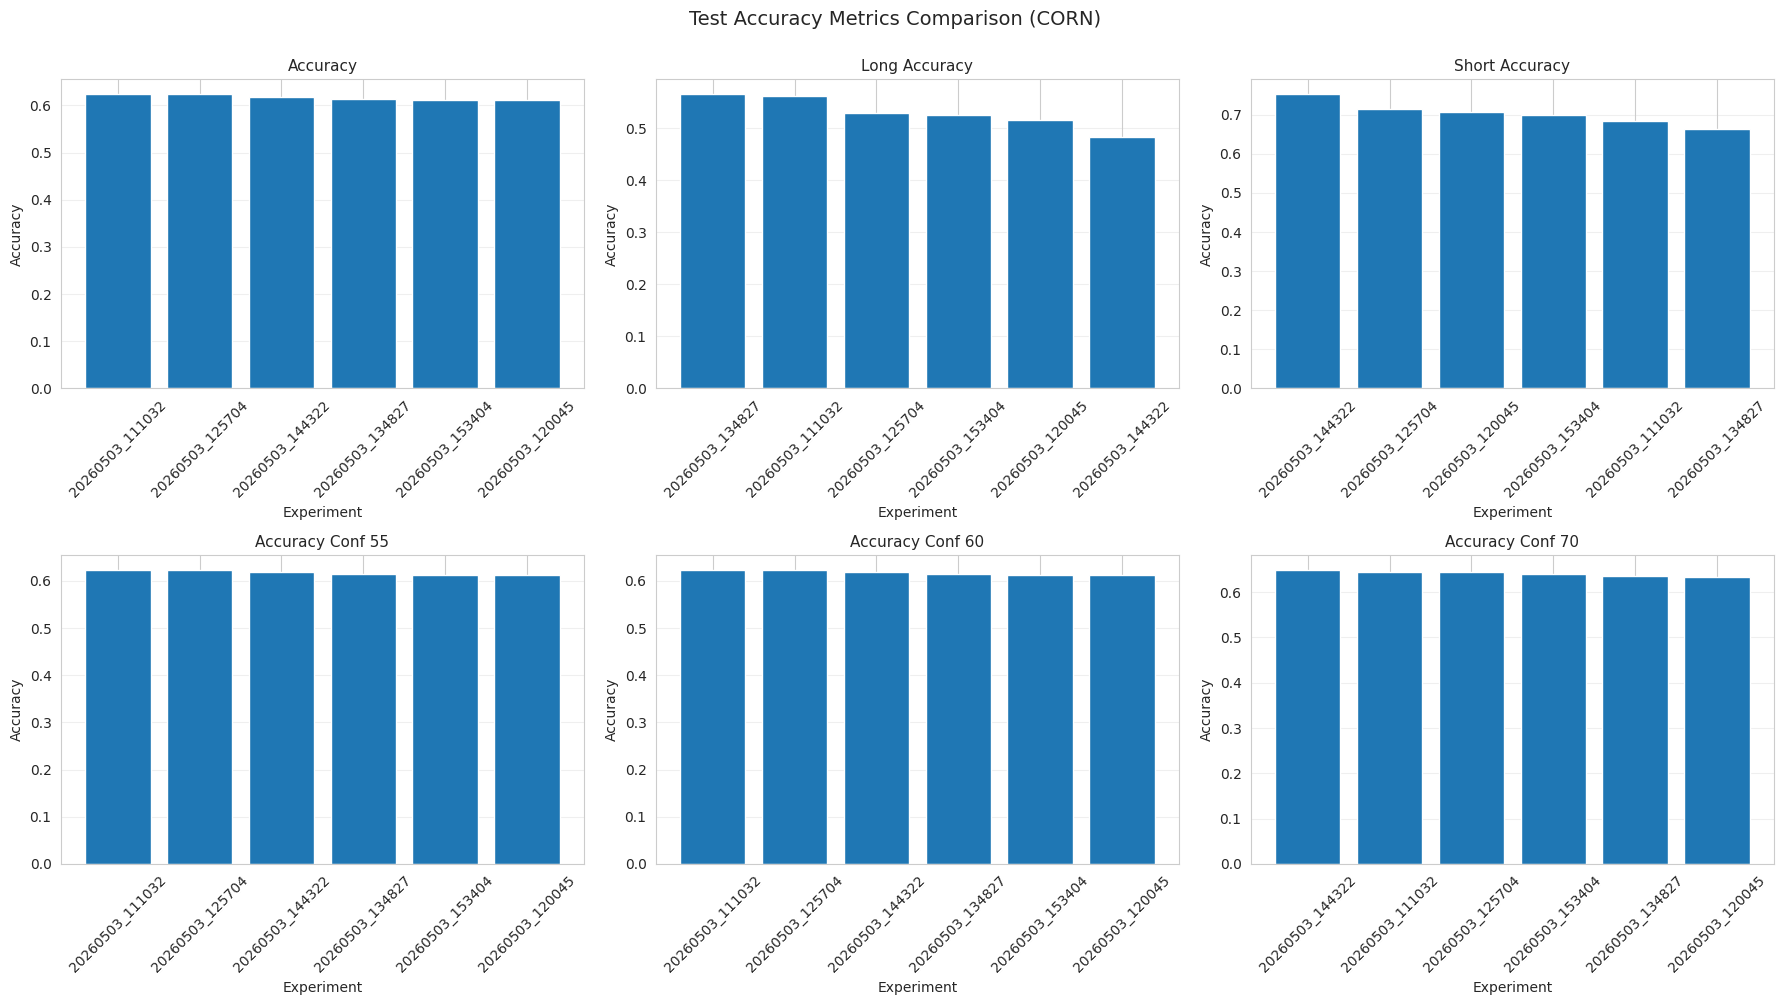

In [38]:
analyzer.plot_all_metrics(metric_type='test', symbol=SYMBOL_FILTER)

## 4. Test Overall Accuracy Comparison

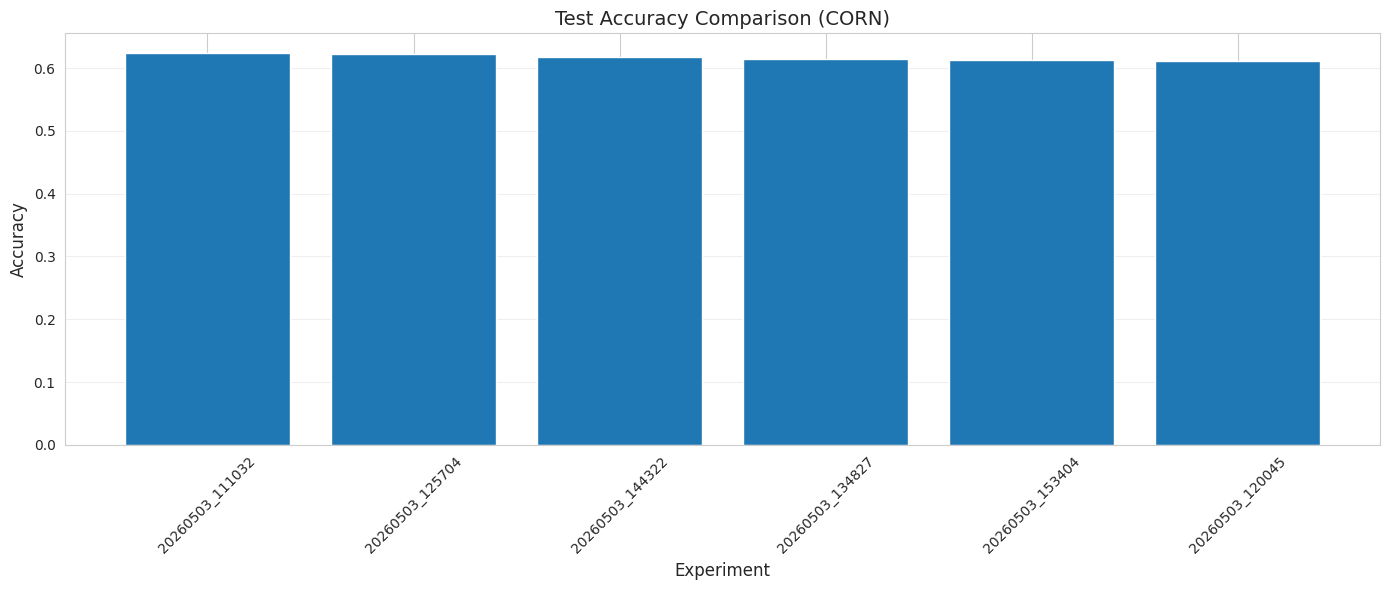

In [39]:
analyzer.plot_comparison(metric='accuracy', metric_type='test', symbol=SYMBOL_FILTER)

## 5. Individual Metric Comparisons (Validation)

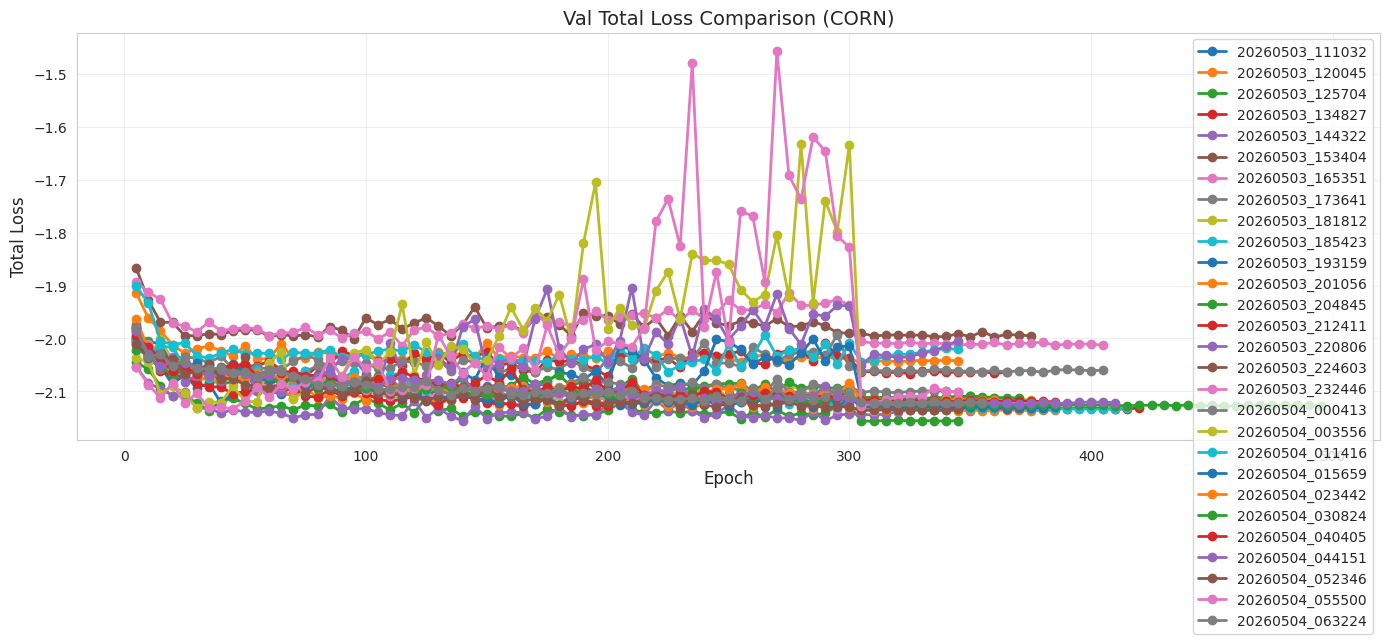

In [40]:
# Total Loss
analyzer.plot_comparison(metric='total_loss', metric_type='val', symbol=SYMBOL_FILTER)

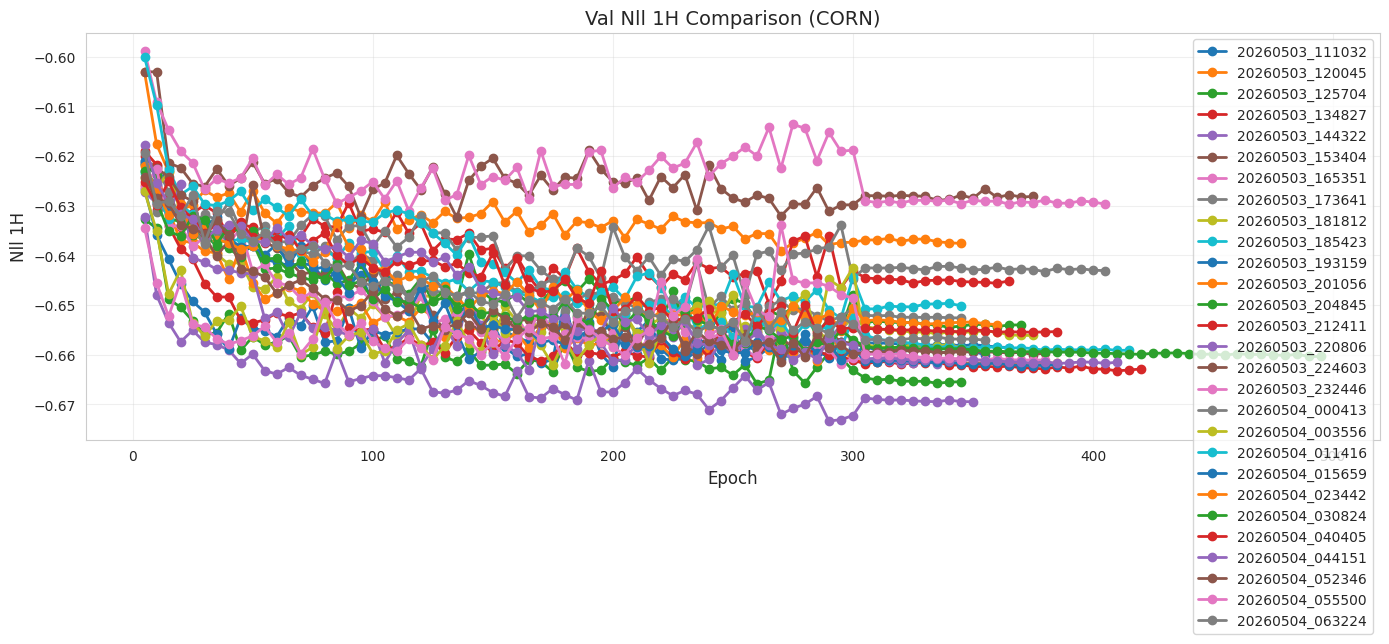

In [41]:
# NLL-1H Loss
analyzer.plot_comparison(metric='nll_1h', metric_type='val', symbol=SYMBOL_FILTER)

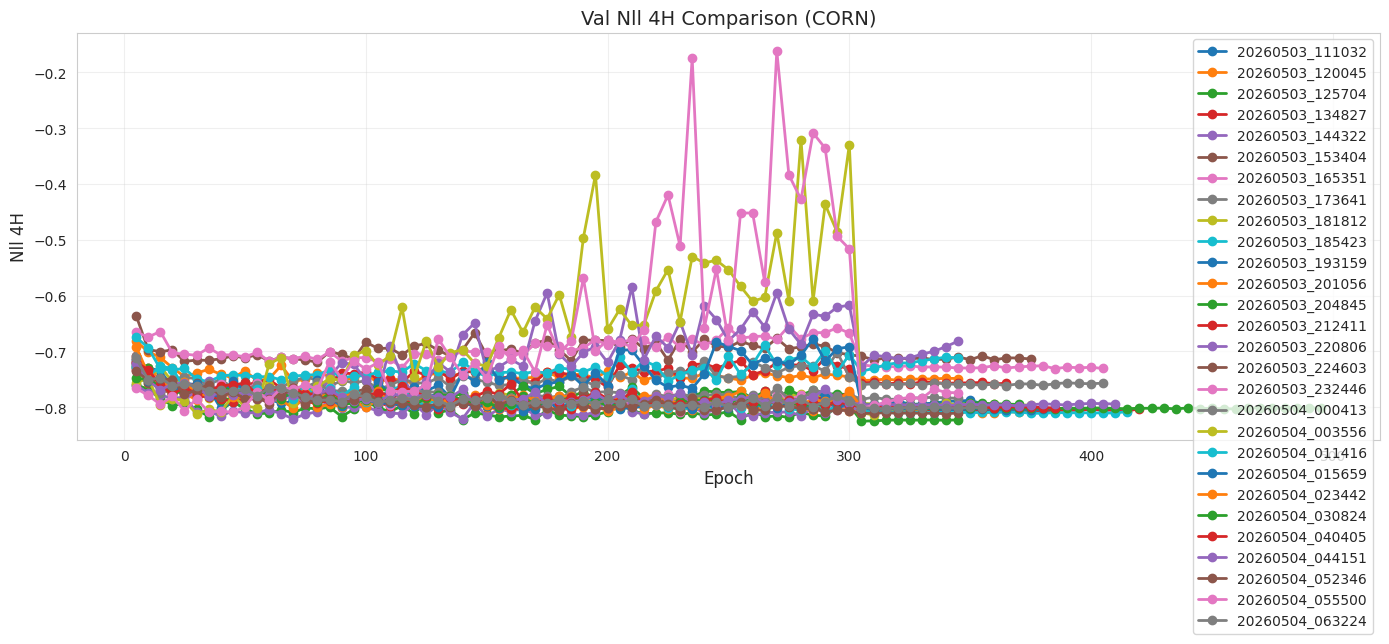

In [42]:
# NLL-4H Loss
analyzer.plot_comparison(metric='nll_4h', metric_type='val', symbol=SYMBOL_FILTER)

## 6. Custom Analysis - Compare Specific Metrics

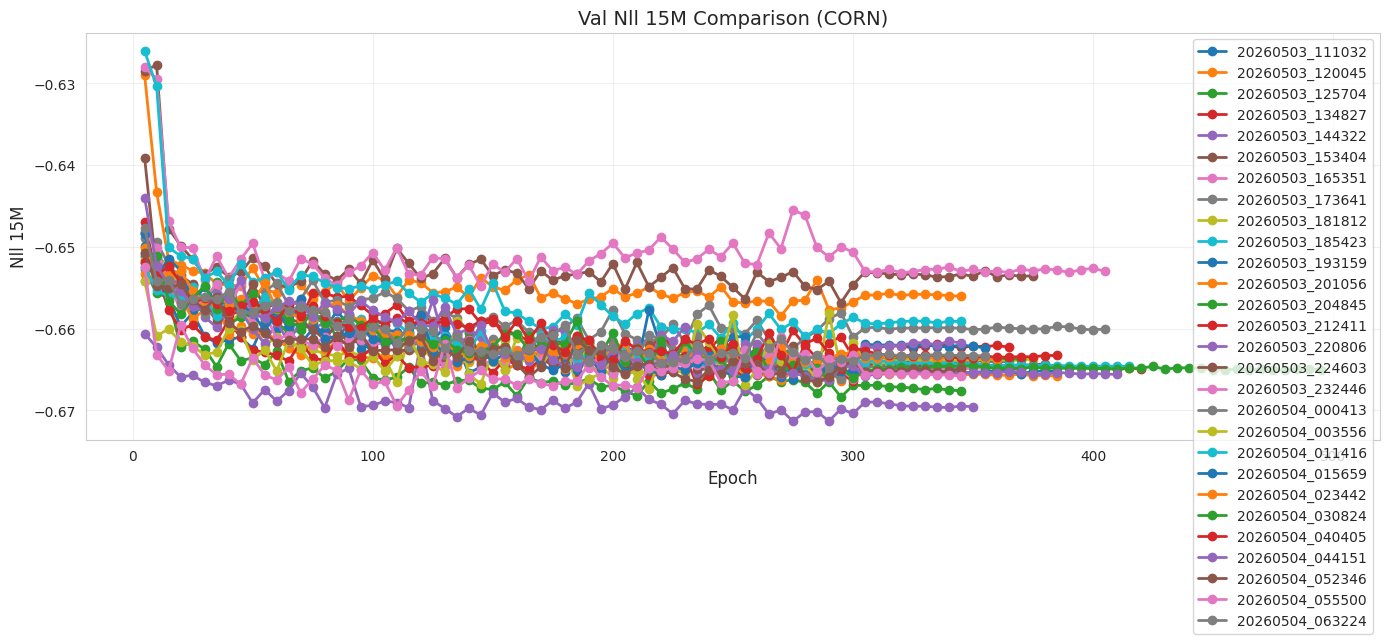

In [43]:
# You can modify these parameters to plot different metrics
# Available metrics: 'total_loss', 'nll_15m', 'nll_1h', 'nll_4h'
# SYMBOL_FILTER: 'all', 'cnh', or 'corn'

# Example: Compare 15m NLL Loss
analyzer.plot_comparison(metric='nll_15m', metric_type='val', symbol=SYMBOL_FILTER)

## 7. Advanced Analysis - Final Metrics Table

In [44]:
# Create a detailed comparison table (filtered)
comparison_data = []
filtered_experiments = analyzer._filter_experiments(SYMBOL_FILTER)

for exp_name, exp_data in filtered_experiments.items():
    if 'val_metrics' in exp_data:
        val_df = exp_data['val_metrics']
        best_idx = val_df['total_loss'].idxmin()
        best_epoch = int(val_df.iloc[best_idx]['epoch'])

        row = {
            'Experiment': exp_name,
            'Symbol': exp_data.get('symbol', 'UNKNOWN'),
            'Final Total Loss': f"{val_df['total_loss'].iloc[-1]:.4f}",
            'Best Total Loss': f"{val_df.loc[best_idx, 'total_loss']:.4f}",
            'Best Epoch': best_epoch,
            'Final NLL-15m': f"{val_df['nll_15m'].iloc[-1]:.4f}",
            'Final NLL-1h': f"{val_df['nll_1h'].iloc[-1]:.4f}",
            'Final NLL-4h': f"{val_df['nll_4h'].iloc[-1]:.4f}",
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
filter_name = analyzer._normalize_symbol(SYMBOL_FILTER)
print("\n" + "="*150)
print(f"FINAL METRICS COMPARISON (VALIDATION SET) - {filter_name}")
print("="*150)
if comparison_df.empty:
    print("No experiment found for this symbol filter.")
else:
    print(comparison_df.to_string(index=False))
print("="*150 + "\n")


FINAL METRICS COMPARISON (VALIDATION SET) - CORN
     Experiment Symbol Final Total Loss Best Total Loss  Best Epoch Final NLL-15m Final NLL-1h Final NLL-4h
20260503_111032   CORN          -2.1193         -2.1229         325       -0.6640      -0.6586      -0.7967
20260503_120045   CORN          -2.0422         -2.0451         255       -0.6561      -0.6376      -0.7485
20260503_125704   CORN          -2.1555         -2.1566         305       -0.6676      -0.6654      -0.8225
20260503_134827   CORN          -2.0645         -2.0716         200       -0.6623      -0.6451      -0.7571
20260503_144322   CORN          -2.1367         -2.1557         140       -0.6696      -0.6695      -0.7977
20260503_153404   CORN          -1.9951         -2.0002          95       -0.6535      -0.6282      -0.7134
20260503_165351   CORN          -2.0131         -2.0137         115       -0.6530      -0.6297      -0.7304
20260503_173641   CORN          -2.0601         -2.0657         195       -0.6601     